In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
from matplotlib.ticker import AutoLocator, AutoMinorLocator, LogLocator
from matplotlib.colors import Normalize
import glob
from scipy.interpolate import griddata
from pathlib import Path
import h5py
import sys
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# Where am I running?
try:
    # Normal script
    here = Path(__file__).resolve().parent
except NameError:
    # Notebook / REPL
    here = Path.cwd()

phys_const_path = (here / '..' / 'phys_const').resolve()
sys.path.append(str(phys_const_path))

nsm_plots_path = (here / '..' / 'nsm_plots').resolve()
sys.path.append(str(nsm_plots_path))

nsm_plots_postproc = (here / '..' / 'nsm_instabilities').resolve()
sys.path.append(str(nsm_plots_postproc))

import phys_const as pc
import plot_functions as pf
import functions_angular_crossings as fac

### Reading hdf5 data

In [2]:
dir_last = '/home/erick/software/devscrpts/gw170817_paper_plots/nsmcell_15_48_15_doma_48-1-1cm_cells_192-1-1_att_1_dt_1e-12s_novac_nomat_sinus_plt1500000_particles_angular_distributions.h5'

with h5py.File(dir_last, "r") as hf:

    # Read ELN angular distribution
    phi_eln_xln_fi_last = hf["phi_eln_xln_fi"][:]
    mu_eln_xln_fi_last = hf["mu_eln_xln_fi"][:]
    G_eln_xln_fi_last = hf["G_eln_xln_fi"][:]
    phi_eln_xln_fp_last = hf["phi_eln_xln_fp"][:]
    mu_eln_xln_fp_last = hf["mu_eln_xln_fp"][:]
    G_eln_xln_fp_last = hf["G_eln_xln_fp"][:]

    # Read e (nu_e) angular distribution
    phi_e_fi_last = hf["phi_e_fi"][:]
    mu_e_fi_last = hf["mu_e_fi"][:]
    G_e_fi_last = hf["G_e_fi"][:]
    phi_e_fp_last = hf["phi_e_fp"][:]
    mu_e_fp_last = hf["mu_e_fp"][:]
    G_e_fp_last = hf["G_e_fp"][:]

    # Read ebar (anti-nu_e) angular distribution
    phi_ebar_fi_last = hf["phi_ebar_fi"][:]
    mu_ebar_fi_last = hf["mu_ebar_fi"][:]
    G_ebar_fi_last = hf["G_ebar_fi"][:]
    phi_ebar_fp_last = hf["phi_ebar_fp"][:]
    mu_ebar_fp_last = hf["mu_ebar_fp"][:]
    G_ebar_fp_last = hf["G_ebar_fp"][:]

    # Read u (nu_x) angular distribution
    phi_u_fi_last = hf["phi_u_fi"][:]
    mu_u_fi_last = hf["mu_u_fi"][:]
    G_u_fi_last = hf["G_u_fi"][:]
    phi_u_fp_last = hf["phi_u_fp"][:]
    mu_u_fp_last = hf["mu_u_fp"][:]
    G_u_fp_last = hf["G_u_fp"][:]

    # Read bh shadow
    phi_bh_shadow_last = hf["phi_bh_shadow"][:]
    mu_bh_shadow_last = hf["mu_bh_shadow"][:]

dir_init = '/home/erick/software/devscrpts/gw170817_paper_plots/nsmcell_15_48_15_doma_48-1-1cm_cells_192-1-1_att_1_dt_1e-12s_novac_nomat_sinus_plt00000_particles_angular_distributions.h5'

with h5py.File(dir_init, "r") as hf:

    # Read ELN angular distribution
    phi_eln_xln_fi_init = hf["phi_eln_xln_fi"][:]
    mu_eln_xln_fi_init = hf["mu_eln_xln_fi"][:]
    G_eln_xln_fi_init = hf["G_eln_xln_fi"][:]
    phi_eln_xln_fp_init = hf["phi_eln_xln_fp"][:]
    mu_eln_xln_fp_init = hf["mu_eln_xln_fp"][:]
    G_eln_xln_fp_init = hf["G_eln_xln_fp"][:]

    # Read e (nu_e) angular distribution
    phi_e_fi_init = hf["phi_e_fi"][:]
    mu_e_fi_init = hf["mu_e_fi"][:]
    G_e_fi_init = hf["G_e_fi"][:]
    phi_e_fp_init = hf["phi_e_fp"][:]
    mu_e_fp_init = hf["mu_e_fp"][:]
    G_e_fp_init = hf["G_e_fp"][:]

    # Read ebar (anti-nu_e) angular distribution
    phi_ebar_fi_init = hf["phi_ebar_fi"][:]
    mu_ebar_fi_init = hf["mu_ebar_fi"][:]
    G_ebar_fi_init = hf["G_ebar_fi"][:]
    phi_ebar_fp_init = hf["phi_ebar_fp"][:]
    mu_ebar_fp_init = hf["mu_ebar_fp"][:]
    G_ebar_fp_init = hf["G_ebar_fp"][:]

    # Read u (nu_x) angular distribution
    phi_u_fi_init = hf["phi_u_fi"][:]
    mu_u_fi_init = hf["mu_u_fi"][:]
    G_u_fi_init = hf["G_u_fi"][:]
    phi_u_fp_init = hf["phi_u_fp"][:]
    mu_u_fp_init = hf["mu_u_fp"][:]
    G_u_fp_init = hf["G_u_fp"][:]

    # Read bh shadow
    phi_bh_shadow_init = hf["phi_bh_shadow"][:]
    mu_bh_shadow_init = hf["mu_bh_shadow"][:]


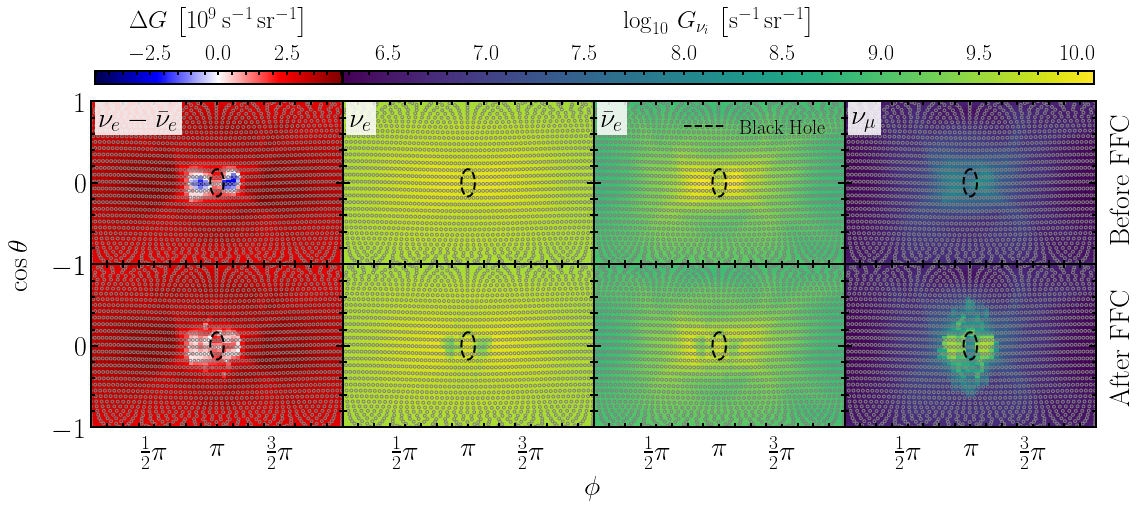

In [3]:
def plot_colored_lines_grid(y_list, color_maps, titles, filename,
                            ylowerlimit=None, yupperlimit=None):
    fig, axs = plt.subplots(2, 4, figsize=(18, 6),
                            sharex=True, sharey=True,
                            gridspec_kw=dict(hspace=0.0, wspace=0.0))
    axs = axs.flatten()

    for i, y in enumerate(y_list):

        ax = axs[i]

        c = ax.pcolormesh(y[3], y[4], y[5], shading='auto', cmap=color_maps[i], vmin=ylowerlimit[i], vmax=yupperlimit[i])
        ax.scatter(y[0], y[1], c=y[2], cmap=color_maps[i], vmin=ylowerlimit[i], vmax=yupperlimit[i], s=8, edgecolor='gray')
        ax.plot(phi_bh_shadow_init, mu_bh_shadow_init, color='black', linestyle='--', linewidth=2, label='Black Hole')
        # Add legend for the black hole shadow just in the first panel
        if i == 2:
            ax.legend(loc='upper right', fontsize=20, frameon=False)
        
        # ax.text(0.03, 0.15, titles[i], transform=ax.transAxes, fontsize=22,
        #     verticalalignment='top', horizontalalignment='left',
        #     bbox=dict(facecolor='none', alpha=0.7, edgecolor='none'))

        # Set horizontal axis in angles from 0 to 2pi, showing integers of pi and half fractions
        ax.set_xlim(0, 2 * np.pi)
        ax.set_xticks([0.5 * np.pi, 1.0 * np.pi, 1.5 * np.pi])
        ax.set_xticklabels([r'$\frac{1}{2}\pi$', r'$\pi$', r'$\frac{3}{2}\pi$'], fontsize=28)
        ax.set_ylim(-1, 1)
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=28)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

    # Shared axis labels
    fig.text(0.512, -0.03, r'$\phi$', ha='center', fontsize=28)
    fig.text(0.06, 0.5, r'$\cos \theta$', va='center', rotation='vertical', fontsize=28)

    # --- Colorbars per column, on top with ticks/labels above ---
    for col in range(4):  # three columns

        norm = Normalize(ylowerlimit[col], vmax=yupperlimit[col])
        cmap = plt.cm.get_cmap(color_maps[col])
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        if col==0:
            # Position: [left, bottom, width, height] in figure coords
            left = 0.128 + col * (0.188+0.005)
            bottom = 0.92  # put high at top
            width = 0.19
            height = 0.03
            cax = fig.add_axes([left, bottom, width, height])
            cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
        if col==1:
            # Position: [left, bottom, width, height] in figure coords
            left = 0.1263 + col * (0.188+0.005)
            bottom = 0.92  # put high at top
            width = 0.188*3+0.0155
            height = 0.03
            cax = fig.add_axes([left, bottom, width, height])
            cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')

        # Put ticks + label above
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')
        cbar.ax.xaxis.label.set_fontsize(28)
        if col==0:
            cbar.set_label(r'$\Delta G\,\left[10^9\,\mathrm{s}^{-1}\,\mathrm{sr}^{-1}\right]$', fontsize=25, labelpad=16)
        else:
            cbar.set_label(r'$\log_{10}\, G_{\nu_i}\,\left[\mathrm{s}^{-1}\,\mathrm{sr}^{-1}\right]$', fontsize=25, labelpad=16)
        cbar.ax.xaxis.set_minor_locator(AutoMinorLocator())

        ax_top = axs[col]
        ax_top.text(
            0.03,
            0.97,
            titles[col],
            transform=ax_top.transAxes,
            fontsize=28,
            ha='left',
            va='top',
            color='black',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.85),
        )

    fig.text(0.92, 0.7, 'Before FFC', rotation='vertical', fontsize=28,
             va='center', ha='center')
    fig.text(0.92, 0.31, 'After FFC', rotation='vertical', fontsize=28,
             va='center', ha='center')
    
    # Save and show
    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=500)
    plt.show()
    plt.close(fig)

a=0
b=-485
c=None

Gmin = 1.86834413e+06
Gmax = 1.21471491e+10

Gmin = np.log10(Gmin)
Gmax = np.log10(Gmax)

normalization_to_eln = 1e9

plot_colored_lines_grid(
    # y_list = [
    #     [phi_eln_xln_fi_init, mu_eln_xln_fi_init, G_eln_xln_fi_init/1e9, phi_eln_xln_fp_init, mu_eln_xln_fp_init, G_eln_xln_fp_init/1e9],
    #     [phi_e_fi_init, mu_e_fi_init,             G_e_fi_init      /1e9, phi_e_fp_init, mu_e_fp_init,             G_e_fp_init      /1e9],
    #     [phi_ebar_fi_init, mu_ebar_fi_init,       G_ebar_fi_init   /1e9, phi_ebar_fp_init, mu_ebar_fp_init,       G_ebar_fp_init   /1e9],
    #     [phi_u_fi_init, mu_u_fi_init,             G_u_fi_init      /1e9, phi_u_fp_init, mu_u_fp_init,             G_u_fp_init      /1e9],
    #     [phi_eln_xln_fi_last, mu_eln_xln_fi_last, G_eln_xln_fi_last/1e9, phi_eln_xln_fp_last, mu_eln_xln_fp_last, G_eln_xln_fp_last/1e9],
    #     [phi_e_fi_last, mu_e_fi_last,             G_e_fi_last      /1e9, phi_e_fp_last, mu_e_fp_last,             G_e_fp_last      /1e9],
    #     [phi_ebar_fi_last, mu_ebar_fi_last,       G_ebar_fi_last   /1e9, phi_ebar_fp_last, mu_ebar_fp_last,       G_ebar_fp_last   /1e9],
    #     [phi_u_fi_last, mu_u_fi_last,             G_u_fi_last      /1e9, phi_u_fp_last, mu_u_fp_last,             G_u_fp_last      /1e9],
    # ],
    y_list = [
        [phi_eln_xln_fi_init, mu_eln_xln_fi_init, G_eln_xln_fi_init/normalization_to_eln, phi_eln_xln_fp_init, mu_eln_xln_fp_init, G_eln_xln_fp_init/normalization_to_eln],
        [phi_e_fi_init, mu_e_fi_init,             np.log10(G_e_fi_init      ), phi_e_fp_init, mu_e_fp_init,             np.log10(G_e_fp_init      )],
        [phi_ebar_fi_init, mu_ebar_fi_init,       np.log10(G_ebar_fi_init   ), phi_ebar_fp_init, mu_ebar_fp_init,       np.log10(G_ebar_fp_init   )],
        [phi_u_fi_init, mu_u_fi_init,             np.log10(G_u_fi_init      ), phi_u_fp_init, mu_u_fp_init,             np.log10(G_u_fp_init      )],
        [phi_eln_xln_fi_last, mu_eln_xln_fi_last, G_eln_xln_fi_last/normalization_to_eln, phi_eln_xln_fp_last, mu_eln_xln_fp_last, G_eln_xln_fp_last/normalization_to_eln],
        [phi_e_fi_last, mu_e_fi_last,             np.log10(G_e_fi_last      ), phi_e_fp_last, mu_e_fp_last,             np.log10(G_e_fp_last      )],
        [phi_ebar_fi_last, mu_ebar_fi_last,       np.log10(G_ebar_fi_last   ), phi_ebar_fp_last, mu_ebar_fp_last,       np.log10(G_ebar_fp_last   )],
        [phi_u_fi_last, mu_u_fi_last,             np.log10(G_u_fi_last      ), phi_u_fp_last, mu_u_fp_last,             np.log10(G_u_fp_last      )],
    ],
    color_maps=[
        'seismic', 'viridis', 'viridis', 'viridis',
        'seismic', 'viridis', 'viridis', 'viridis',],
    titles = [
        r'$\nu_e - \bar{\nu}_e$', 
        r'$\nu_e$', 
        r'$\bar{\nu}_e$', 
        r'$\nu_\mu$', 
    ],
    filename = f"plots/angular_distribution.png",
    # ylowerlimit = np.array([-4.51833597e+09,6.71444161e+08,6.71444161e+08,6.71444161e+08,-4.51833597e+09,6.71444161e+08,6.71444161e+08,6.71444161e+08])/1e9,
    # yupperlimit = np.array([+4.51833597e+09,1.21471491e+10,1.21471491e+10,1.21471491e+10,+4.51833597e+09,1.21471491e+10,1.21471491e+10,1.21471491e+10])/1e9
    ylowerlimit = np.array([-4.51833597e+09/normalization_to_eln,Gmin,Gmin,Gmin,-4.51833597e+09/normalization_to_eln,Gmin,Gmin,Gmin]),
    yupperlimit = np.array([+4.51833597e+09/normalization_to_eln,Gmax,Gmax,Gmax,+4.51833597e+09/normalization_to_eln,Gmax,Gmax,Gmax])
)


In [4]:
dir_last = '/home/erick/software/devscrpts/gw170817_paper_plots/1506_ppEb_plt00384_particles_48_48_40_angular_distributions.h5'
with h5py.File(dir_last, "r") as hf:

    # Read ELN angular distribution
    phi_eln_xln_fi_484840 = hf["phi_eln_xln_fi"][:]
    mu_eln_xln_fi_484840 = hf["mu_eln_xln_fi"][:]
    G_eln_xln_fi_484840 = hf["G_eln_xln_fi"][:]
    phi_eln_xln_fp_484840 = hf["phi_eln_xln_fp"][:]
    mu_eln_xln_fp_484840 = hf["mu_eln_xln_fp"][:]
    G_eln_xln_fp_484840 = hf["G_eln_xln_fp"][:]

    # Read e (nu_e) angular distribution
    phi_e_fi_484840 = hf["phi_e_fi"][:]
    mu_e_fi_484840 = hf["mu_e_fi"][:]
    G_e_fi_484840 = hf["G_e_fi"][:]
    phi_e_fp_484840 = hf["phi_e_fp"][:]
    mu_e_fp_484840 = hf["mu_e_fp"][:]
    G_e_fp_484840 = hf["G_e_fp"][:]

    # Read ebar (anti-nu_e) angular distribution
    phi_ebar_fi_484840 = hf["phi_ebar_fi"][:]
    mu_ebar_fi_484840 = hf["mu_ebar_fi"][:]
    G_ebar_fi_484840 = hf["G_ebar_fi"][:]
    phi_ebar_fp_484840 = hf["phi_ebar_fp"][:]
    mu_ebar_fp_484840 = hf["mu_ebar_fp"][:]
    G_ebar_fp_484840 = hf["G_ebar_fp"][:]

    # Read u (nu_x) angular distribution
    phi_u_fi_484840 = hf["phi_u_fi"][:]
    mu_u_fi_484840 = hf["mu_u_fi"][:]
    G_u_fi_484840 = hf["G_u_fi"][:]
    phi_u_fp_484840 = hf["phi_u_fp"][:]
    mu_u_fp_484840 = hf["mu_u_fp"][:]
    G_u_fp_484840 = hf["G_u_fp"][:]

    # Read bh shadow
    phi_bh_shadow_484840 = hf["phi_bh_shadow"][:]
    mu_bh_shadow_484840 = hf["mu_bh_shadow"][:]

dir_init = '/home/erick/software/devscrpts/gw170817_paper_plots/1506_ppEb_plt00384_particles_88_48_40_angular_distributions.h5'

with h5py.File(dir_init, "r") as hf:

    # Read ELN angular distribution
    phi_eln_xln_fi_884840 = hf["phi_eln_xln_fi"][:]
    mu_eln_xln_fi_884840 = hf["mu_eln_xln_fi"][:]
    G_eln_xln_fi_884840 = hf["G_eln_xln_fi"][:]
    phi_eln_xln_fp_884840 = hf["phi_eln_xln_fp"][:]
    mu_eln_xln_fp_884840 = hf["mu_eln_xln_fp"][:]
    G_eln_xln_fp_884840 = hf["G_eln_xln_fp"][:]

    # Read e (nu_e) angular distribution
    phi_e_fi_884840 = hf["phi_e_fi"][:]
    mu_e_fi_884840 = hf["mu_e_fi"][:]
    G_e_fi_884840 = hf["G_e_fi"][:]
    phi_e_fp_884840 = hf["phi_e_fp"][:]
    mu_e_fp_884840 = hf["mu_e_fp"][:]
    G_e_fp_884840 = hf["G_e_fp"][:]

    # Read ebar (anti-nu_e) angular distribution
    phi_ebar_fi_884840 = hf["phi_ebar_fi"][:]
    mu_ebar_fi_884840 = hf["mu_ebar_fi"][:]
    G_ebar_fi_884840 = hf["G_ebar_fi"][:]
    phi_ebar_fp_884840 = hf["phi_ebar_fp"][:]
    mu_ebar_fp_884840 = hf["mu_ebar_fp"][:]
    G_ebar_fp_884840 = hf["G_ebar_fp"][:]

    # Read u (nu_x) angular distribution
    phi_u_fi_884840 = hf["phi_u_fi"][:]
    mu_u_fi_884840 = hf["mu_u_fi"][:]
    G_u_fi_884840 = hf["G_u_fi"][:]
    phi_u_fp_884840 = hf["phi_u_fp"][:]
    mu_u_fp_884840 = hf["mu_u_fp"][:]
    G_u_fp_884840 = hf["G_u_fp"][:]

    # Read bh shadow
    phi_bh_shadow_884840 = hf["phi_bh_shadow"][:]
    mu_bh_shadow_884840 = hf["mu_bh_shadow"][:]


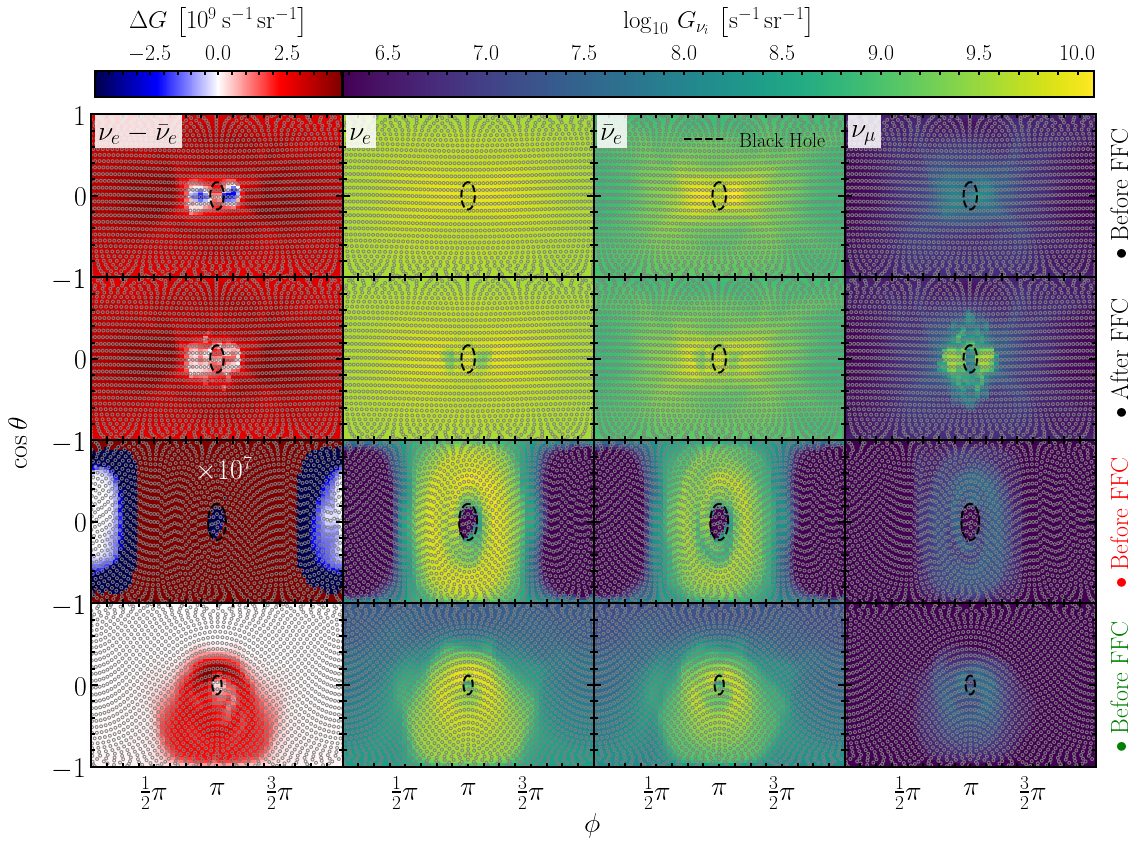

In [5]:
def plot_colored_lines_grid(y_list, color_maps, titles, filename,
                            ylowerlimit=None, yupperlimit=None):
    fig, axs = plt.subplots(4, 4, figsize=(18, 12),
                            sharex=True, sharey=True,
                            gridspec_kw=dict(hspace=0.0, wspace=0.0))
    axs = axs.flatten()

    for i, y in enumerate(y_list):

        ax = axs[i]

        c = ax.pcolormesh(y[3], y[4], y[5], shading='auto', cmap=color_maps[i], vmin=ylowerlimit[i], vmax=yupperlimit[i])
        ax.scatter(y[0], y[1], c=y[2], cmap=color_maps[i], vmin=ylowerlimit[i], vmax=yupperlimit[i], s=8, edgecolor='gray')
        ax.plot(y[6], y[7], color='black', linestyle='--', linewidth=2, label='Black Hole')
        # Add legend for the black hole shadow just in one panel per row
        if i == 2:
            ax.legend(loc='upper right', fontsize=20, frameon=False)
        
        # ax.text(0.03, 0.15, titles[i], transform=ax.transAxes, fontsize=22,
        #     verticalalignment='top', horizontalalignment='left',
        #     bbox=dict(facecolor='none', alpha=0.7, edgecolor='none'))

        # Set horizontal axis in angles from 0 to 2pi, showing integers of pi and half fractions
        ax.set_xlim(0, 2 * np.pi)
        ax.set_xticks([0.5 * np.pi, 1.0 * np.pi, 1.5 * np.pi])
        ax.set_xticklabels([r'$\frac{1}{2}\pi$', r'$\pi$', r'$\frac{3}{2}\pi$'], fontsize=28)
        ax.set_ylim(-1, 1)
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=28)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

    # Shared axis labels
    fig.text(0.512, 0.05, r'$\phi$', ha='center', fontsize=28)
    fig.text(0.06, 0.5, r'$\cos \theta$', va='center', rotation='vertical', fontsize=28)

    # --- Colorbars: one strip above row 1 (top) only ---
    cbar_bottoms = [0.9]
    for cbar_row, bottom in enumerate(cbar_bottoms):
        for col in range(4):
            norm = Normalize(ylowerlimit[col], vmax=yupperlimit[col])
            cmap = plt.cm.get_cmap(color_maps[col])
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            if col == 0:
                left = 0.128 + col * (0.188+0.005)
                width = 0.19
                height = 0.03
                cax = fig.add_axes([left, bottom, width, height])
                cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
            if col == 1:
                left = 0.1263 + col * (0.188+0.005)
                width = 0.188*3+0.0155
                height = 0.03
                cax = fig.add_axes([left, bottom, width, height])
                cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')

            if col in (0, 1):
                cbar.ax.xaxis.set_ticks_position('top')
                cbar.ax.xaxis.set_label_position('top')
                cbar.ax.xaxis.label.set_fontsize(28)
                if col == 0:
                    cbar.set_label(r'$\Delta G\,\left[10^9\,\mathrm{s}^{-1}\,\mathrm{sr}^{-1}\right]$', fontsize=25, labelpad=16)
                else:
                    cbar.set_label(r'$\log_{10}\, G_{\nu_i}\,\left[\mathrm{s}^{-1}\,\mathrm{sr}^{-1}\right]$', fontsize=25, labelpad=16)
                cbar.ax.xaxis.set_minor_locator(AutoMinorLocator())

    # Panel titles (first row only)
    for col in range(4):
        ax_top = axs[col]
        ax_top.text(
            0.03,
            0.97,
            titles[col],
            transform=ax_top.transAxes,
            fontsize=28,
            ha='left',
            va='top',
            color='black',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.85),
        )

    # Row labels: Before FFC, After FFC, Before FFC, After FFC
    fig.text(0.92, 0.79, "\u2022 Before FFC", rotation='vertical', fontsize=24, va='center', ha='center', color='black')
    fig.text(0.92, 0.60, "\u2022 After FFC", rotation='vertical', fontsize=24, va='center', ha='center', color='black')
    fig.text(0.92, 0.41, "\u2022 Before FFC", rotation='vertical', fontsize=24, va='center', ha='center', color='red')
    fig.text(0.23, 0.47, r"$\times 10^7$", rotation='horizontal', fontsize=28, va='center', ha='center', color='white')
    fig.text(0.92, 0.22, "\u2022 Before FFC", rotation='vertical', fontsize=24, va='center', ha='center', color='green')
    # Save and show
    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=500)
    plt.show()
    plt.close(fig)

a=0
b=-485
c=None

Gmin = 1.86834413e+06
Gmax = 1.21471491e+10

Gmin = np.log10(Gmin)
Gmax = np.log10(Gmax)

normalization_to_eln = 1e9

plot_colored_lines_grid(
    # y_list = [
    #     [phi_eln_xln_fi_init, mu_eln_xln_fi_init, G_eln_xln_fi_init/1e9, phi_eln_xln_fp_init, mu_eln_xln_fp_init, G_eln_xln_fp_init/1e9],
    #     [phi_e_fi_init, mu_e_fi_init,             G_e_fi_init      /1e9, phi_e_fp_init, mu_e_fp_init,             G_e_fp_init      /1e9],
    #     [phi_ebar_fi_init, mu_ebar_fi_init,       G_ebar_fi_init   /1e9, phi_ebar_fp_init, mu_ebar_fp_init,       G_ebar_fp_init   /1e9],
    #     [phi_u_fi_init, mu_u_fi_init,             G_u_fi_init      /1e9, phi_u_fp_init, mu_u_fp_init,             G_u_fp_init      /1e9],
    #     [phi_eln_xln_fi_last, mu_eln_xln_fi_last, G_eln_xln_fi_last/1e9, phi_eln_xln_fp_last, mu_eln_xln_fp_last, G_eln_xln_fp_last/1e9],
    #     [phi_e_fi_last, mu_e_fi_last,             G_e_fi_last      /1e9, phi_e_fp_last, mu_e_fp_last,             G_e_fp_last      /1e9],
    #     [phi_ebar_fi_last, mu_ebar_fi_last,       G_ebar_fi_last   /1e9, phi_ebar_fp_last, mu_ebar_fp_last,       G_ebar_fp_last   /1e9],
    #     [phi_u_fi_last, mu_u_fi_last,             G_u_fi_last      /1e9, phi_u_fp_last, mu_u_fp_last,             G_u_fp_last      /1e9],
    # ],
    y_list = [
        [phi_eln_xln_fi_init, mu_eln_xln_fi_init, G_eln_xln_fi_init/normalization_to_eln, phi_eln_xln_fp_init, mu_eln_xln_fp_init, G_eln_xln_fp_init/normalization_to_eln, phi_bh_shadow_init, mu_bh_shadow_init],
        [phi_e_fi_init, mu_e_fi_init,             np.log10(G_e_fi_init      ), phi_e_fp_init, mu_e_fp_init,             np.log10(G_e_fp_init      ), phi_bh_shadow_init, mu_bh_shadow_init],
        [phi_ebar_fi_init, mu_ebar_fi_init,       np.log10(G_ebar_fi_init   ), phi_ebar_fp_init, mu_ebar_fp_init,       np.log10(G_ebar_fp_init   ), phi_bh_shadow_init, mu_bh_shadow_init],
        [phi_u_fi_init, mu_u_fi_init,             np.log10(G_u_fi_init      ), phi_u_fp_init, mu_u_fp_init,             np.log10(G_u_fp_init      ), phi_bh_shadow_init, mu_bh_shadow_init],
        [phi_eln_xln_fi_last, mu_eln_xln_fi_last, G_eln_xln_fi_last/normalization_to_eln, phi_eln_xln_fp_last, mu_eln_xln_fp_last, G_eln_xln_fp_last/normalization_to_eln, phi_bh_shadow_last, mu_bh_shadow_last],
        [phi_e_fi_last, mu_e_fi_last,             np.log10(G_e_fi_last      ), phi_e_fp_last, mu_e_fp_last,             np.log10(G_e_fp_last      ), phi_bh_shadow_last, mu_bh_shadow_last],
        [phi_ebar_fi_last, mu_ebar_fi_last,       np.log10(G_ebar_fi_last   ), phi_ebar_fp_last, mu_ebar_fp_last,       np.log10(G_ebar_fp_last   ), phi_bh_shadow_last, mu_bh_shadow_last],
        [phi_u_fi_last, mu_u_fi_last,             np.log10(G_u_fi_last      ), phi_u_fp_last, mu_u_fp_last,             np.log10(G_u_fp_last      ), phi_bh_shadow_last, mu_bh_shadow_last],
        # Row 3: repeat row 1 (Before FFC) with "484840"
        [phi_eln_xln_fi_484840, mu_eln_xln_fi_484840, 1e7*G_eln_xln_fi_484840/normalization_to_eln, phi_eln_xln_fp_484840, mu_eln_xln_fp_484840, 1e7*G_eln_xln_fp_484840/normalization_to_eln, phi_bh_shadow_484840, mu_bh_shadow_484840],
        [phi_e_fi_484840, mu_e_fi_484840,             np.log10(G_e_fi_484840      ), phi_e_fp_484840, mu_e_fp_484840,             np.log10(G_e_fp_484840      ), phi_bh_shadow_484840, mu_bh_shadow_484840],
        [phi_ebar_fi_484840, mu_ebar_fi_484840,       np.log10(G_ebar_fi_484840   ), phi_ebar_fp_484840, mu_ebar_fp_484840,       np.log10(G_ebar_fp_484840   ), phi_bh_shadow_484840, mu_bh_shadow_484840],
        [phi_u_fi_484840, mu_u_fi_484840,             np.log10(G_u_fi_484840      ), phi_u_fp_484840, mu_u_fp_484840,             np.log10(G_u_fp_484840      ), phi_bh_shadow_484840, mu_bh_shadow_484840],
        # Row 4: repeat row 2 (After FFC)
        [phi_eln_xln_fi_884840, mu_eln_xln_fi_884840, G_eln_xln_fi_884840/normalization_to_eln, phi_eln_xln_fp_884840, mu_eln_xln_fp_884840, G_eln_xln_fp_884840/normalization_to_eln, phi_bh_shadow_884840, mu_bh_shadow_884840],
        [phi_e_fi_884840, mu_e_fi_884840,             np.log10(G_e_fi_884840      ), phi_e_fp_884840, mu_e_fp_884840,             np.log10(G_e_fp_884840      ), phi_bh_shadow_884840, mu_bh_shadow_884840],
        [phi_ebar_fi_884840, mu_ebar_fi_884840,       np.log10(G_ebar_fi_884840   ), phi_ebar_fp_884840, mu_ebar_fp_884840,       np.log10(G_ebar_fp_884840   ), phi_bh_shadow_884840, mu_bh_shadow_884840],
        [phi_u_fi_884840, mu_u_fi_884840,             np.log10(G_u_fi_884840      ), phi_u_fp_884840, mu_u_fp_884840,             np.log10(G_u_fp_884840      ), phi_bh_shadow_884840, mu_bh_shadow_884840],
    ],
    color_maps=[
        'seismic', 'viridis', 'viridis', 'viridis',
        'seismic', 'viridis', 'viridis', 'viridis',
        'seismic', 'viridis', 'viridis', 'viridis',
        'seismic', 'viridis', 'viridis', 'viridis',],
    titles = [
        r'$\nu_e - \bar{\nu}_e$', 
        r'$\nu_e$', 
        r'$\bar{\nu}_e$', 
        r'$\nu_\mu$', 
    ],
    filename = f"plots/angular_distribution.png",
    # ylowerlimit = np.array([-4.51833597e+09,6.71444161e+08,6.71444161e+08,6.71444161e+08,-4.51833597e+09,6.71444161e+08,6.71444161e+08,6.71444161e+08])/1e9,
    # yupperlimit = np.array([+4.51833597e+09,1.21471491e+10,1.21471491e+10,1.21471491e+10,+4.51833597e+09,1.21471491e+10,1.21471491e+10,1.21471491e+10])/1e9
    ylowerlimit = np.array([-4.51833597e+09/normalization_to_eln,Gmin,Gmin,Gmin,-4.51833597e+09/normalization_to_eln,Gmin,Gmin,Gmin,-4.51833597e+09/normalization_to_eln,Gmin,Gmin,Gmin,-4.51833597e+09/normalization_to_eln,Gmin,Gmin,Gmin]),
    yupperlimit = np.array([+4.51833597e+09/normalization_to_eln,Gmax,Gmax,Gmax,+4.51833597e+09/normalization_to_eln,Gmax,Gmax,Gmax,+4.51833597e+09/normalization_to_eln,Gmax,Gmax,Gmax,+4.51833597e+09/normalization_to_eln,Gmax,Gmax,Gmax])
)


### Furier modes

In [6]:
with h5py.File(f"/home/erick/software/devscrpts/gw170817_paper_plots/nsmcell_15_48_15_doma_48-1-1cm_cells_192-1-1_att_1_dt_1e-12s_novac_nomat_sinus_n_furier_evolution.h5", "r") as hf:
    time_fft = hf["time_s"][:]
    lambda_cm_ee = hf["lambda_cm_ee"][:]
    f_lambda_ee = hf["f_lambda_ee"][:]
    lambda_cm_uu = hf["lambda_cm_uu"][:]
    f_lambda_uu = hf["f_lambda_uu"][:]
    lambda_cm_tt = hf["lambda_cm_tt"][:]
    f_lambda_tt = hf["f_lambda_tt"][:]
    lambda_cm_eu = hf["lambda_cm_eu"][:]
    f_lambda_eu = hf["f_lambda_eu"][:]
    lambda_cm_et = hf["lambda_cm_et"][:]
    f_lambda_et = hf["f_lambda_et"][:]
    lambda_cm_ut = hf["lambda_cm_ut"][:]
    f_lambda_ut = hf["f_lambda_ut"][:]


Max ImOmax_inv_s_lsa at index 193: 137139943.8184736
k_x_inv_cm_lsa at max index 193: 2.2933333333333343
ImOmax_inv_s_lsa shape: (301,)
k_x_inv_cm_lsa shape: (301,)
np.max(ImOmax_inv_s_lsa) =  137139943.8184736
np.min(ImOmax_inv_s_lsa) =  3.818865069326016e-06
Max index in f_lambda_eu slice: 112
k (cm^-1) for lambda_cm_tt[b][max index]:
2.0943951023931953
  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array
  alpha: scalar or None
  animated: bool
  backgroundcolor: color
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `.Bbox`
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: color
  figure: `.Figure`
  fontfamily or family: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 

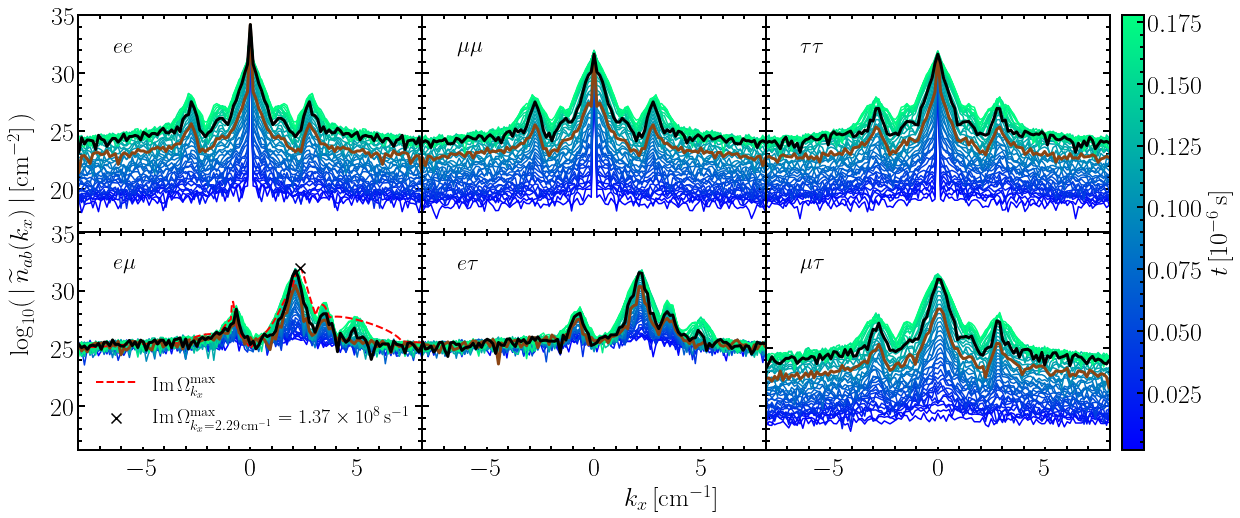

In [7]:
with h5py.File(f"/home/erick/software/devscrpts/gw170817_paper_plots/FFI_LSA_from_julien.h5", "r") as hf:
    ImOmax_inv_s_lsa = hf["ImOmax (1|s)"][:]
    k_x_inv_cm_lsa = hf["k_x (1|cm)"][:]

max_idx = int(np.argmax(ImOmax_inv_s_lsa))
max_val = ImOmax_inv_s_lsa[max_idx]
print(f"Max ImOmax_inv_s_lsa at index {max_idx}: {max_val}")
print(f"k_x_inv_cm_lsa at max index {max_idx}: {k_x_inv_cm_lsa[max_idx]}")

print("ImOmax_inv_s_lsa shape:", ImOmax_inv_s_lsa.shape)
print("k_x_inv_cm_lsa shape:", k_x_inv_cm_lsa.shape)

print("np.max(ImOmax_inv_s_lsa) = ", np.max(ImOmax_inv_s_lsa))
print("np.min(ImOmax_inv_s_lsa) = ", np.min(ImOmax_inv_s_lsa))

ImOmax_inv_s_lsa_for_plot = 7 * ImOmax_inv_s_lsa / 137139943.8184736 + 25  # in 10^8 s^-1

def plot_colored_lines_grid(x, y_list, time_s, titles, suptitle, filename, ylowerlimit=None, yupperlimit=None):
    fig, axs = plt.subplots(2, 3, figsize=(22, 8), sharex=True, sharey=True, gridspec_kw=dict(hspace=0.0, wspace=0.0))
    axs = axs.flatten()

    norm = Normalize(time_s.min(), time_s.max())
    cmap = plt.cm.winter

    for i, y in enumerate(y_list):
        ax = axs[i]
        for j in range(y[1].shape[0]):
            color = cmap(norm(time_s[j]))
            ax.plot(2*np.pi/y[0][j,:], y[1][j, :], color=color)
        if i == 3:
            line, = ax.plot(k_x_inv_cm_lsa, ImOmax_inv_s_lsa_for_plot, color='red', linestyle='dashed', linewidth=2.0)
            # ax_right.plot(k_x_inv_cm_lsa, ImOmax_inv_s_lsa/1e8,
                                # color='black', linestyle='solid', alpha=alphamt)        
            scatter_point = ax.scatter(
                [k_x_inv_cm_lsa[max_idx]],
                [ImOmax_inv_s_lsa_for_plot[max_idx]],
                marker='x',
                color='black',
                s=100.0,
                zorder=10
            )
            legend = ax.legend(
                [line, scatter_point],
                [r'$\mathrm{Im} \, \Omega^{\mathrm{max}}_{k_x}$', r'$\mathrm{Im} \, \Omega^{\mathrm{max}}_{k_x=2.29\,\mathrm{cm}^{-1}} = 1.37\times 10^{8} \,\mathrm{s}^{-1}$'],
                loc='lower left',
                fontsize=20,
                frameon=False
            )
            plt.setp(legend.get_texts())
            
        # Place the title inside the plot, top left corner
        ax.text(0.1, 0.9, titles[i], transform=ax.transAxes, fontsize=22,
            verticalalignment='top', horizontalalignment='left', bbox=dict(facecolor='None', alpha=1.0, edgecolor='none'))

        # ax.set_xlim(np.nanmin(2*np.pi/y[0][j,:]), np.nanmax(2*np.pi/y[0][j,:]))
        ax.set_xlim(-8,8)

        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(axis='both', labelsize=26)
        # if i % 3 == 0:
        #     ax.set_ylabel(r'$\log(n\, [\mathrm{cm}^{-3}])$')
        # if i >= 3:
        #     ax.set_xlabel(r'$\log(E\, [\mathrm{MeV}])$')
    
    # fig.text(0.19, 0.465, r'$\mathrm{Im} \, \Omega^{\mathrm{max}}_{k_x=2.29\,\mathrm{cm}^{-1}} = 1.37\times 10^{8} \,\mathrm{s}^{-1}$', va='center', color = 'red', rotation='horizontal', fontsize=18)

    for i, y in enumerate(y_list):
        flag_lsa_plot_1 = True
        flag_lsa_plot_2 = True
        ax = axs[i]
        for j in range(y[1].shape[0]):
        # t = 0.13e-6 is saturation time
            if time_s[j] > 0.13 and flag_lsa_plot_1:
                ax.plot(2*np.pi/y[0][j,:], y[1][j, :], color='black', linestyle='solid', linewidth=3, alpha=1.0)
                flag_lsa_plot_1 = False
            if time_s[j] > 0.10 and flag_lsa_plot_2:
                ax.plot(2*np.pi/y[0][j,:], y[1][j, :], color='saddlebrown', linestyle='solid', linewidth=3, alpha=1.0)
                flag_lsa_plot_2 = False

    fig.text(0.5, 0.03, r'$k_x\, [\mathrm{cm}^{-1}] $', ha='center', fontsize=26)
    fig.text(0.08, 0.5, r'$\log_{10}(\,|\, \widetilde{n}_{ab}(k_x)\,| \, [\mathrm{cm}^{-2}]\,)$', va='center', rotation='vertical', fontsize=26)

    # Shared colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs, location='right', shrink=1.0, pad=0.01)
    cbar.set_label(r'$t \, [10^{-6}\,\mathrm{s}]$', fontsize=26)
    cbar.ax.yaxis.set_minor_locator(AutoMinorLocator())
    cbar.ax.tick_params(axis='both', labelsize=26)

    # Super title
    fig.suptitle(suptitle, fontsize=22)

    # Save and show
    if filename:
        plt.savefig(filename, bbox_inches='tight')
    plt.show()
    plt.close(fig)

a=1
b=90
c=2

max_log_idx_eu = int(np.nanargmax(np.log10(f_lambda_eu[b])))
print("Max index in f_lambda_eu slice:", max_log_idx_eu)
k_tt_slice = 2 * np.pi / lambda_cm_tt[b][max_log_idx_eu]
print("k (cm^-1) for lambda_cm_tt[b][max index]:")
print(k_tt_slice)

plot_colored_lines_grid(
    x = lambda_cm_ee,
    y_list = [
        [lambda_cm_ee[a:b:c], np.log10(f_lambda_ee[a:b:c])],
        [lambda_cm_uu[a:b:c], np.log10(f_lambda_uu[a:b:c])],
        [lambda_cm_tt[a:b:c], np.log10(f_lambda_tt[a:b:c])],
        [lambda_cm_eu[a:b:c], np.log10(f_lambda_eu[a:b:c])],
        [lambda_cm_et[a:b:c], np.log10(f_lambda_et[a:b:c])],
        [lambda_cm_ut[a:b:c], np.log10(f_lambda_ut[a:b:c])]
    ],
    time_s = time_fft[a:b:c]/1e-6,
    titles = [
        r'$ee$', r'$\mu\mu$', r'$\tau\tau$',
        r'$e\mu$', r'$e\tau$', r'$\mu\tau$'
    ],
    suptitle = '',
    filename = f"plots/n_furier.pdf",
    ylowerlimit = None,
    yupperlimit = None
)

### Number density plots

In [8]:
with h5py.File(f"/home/erick/software/devscrpts/gw170817_paper_plots/nsmcell_15_48_15_doma_48-1-1cm_cells_48-1-1_att_1_dt_1e-12s_novac_nomat_sinus_n_average_time_evolution.h5", "r") as hf:
    time_s_48cells = hf["time_s"][:]
    n_ee_ave_inv_ccm_48cells = hf["n_ee_ave_inv_ccm"][:]
    n_uu_ave_inv_ccm_48cells = hf["n_uu_ave_inv_ccm"][:]
    n_tt_ave_inv_ccm_48cells = hf["n_tt_ave_inv_ccm"][:]
    n_eu_ave_inv_ccm_48cells = hf["n_eu_ave_inv_ccm"][:]
    n_et_ave_inv_ccm_48cells = hf["n_et_ave_inv_ccm"][:]
    n_ut_ave_inv_ccm_48cells = hf["n_ut_ave_inv_ccm"][:]
    nbar_ee_ave_inv_ccm_48cells = hf["nbar_ee_ave_inv_ccm"][:]
    nbar_uu_ave_inv_ccm_48cells = hf["nbar_uu_ave_inv_ccm"][:]
    nbar_tt_ave_inv_ccm_48cells = hf["nbar_tt_ave_inv_ccm"][:]
    nbar_eu_ave_inv_ccm_48cells = hf["nbar_eu_ave_inv_ccm"][:]
    nbar_et_ave_inv_ccm_48cells = hf["nbar_et_ave_inv_ccm"][:]
    nbar_ut_ave_inv_ccm_48cells = hf["nbar_ut_ave_inv_ccm"][:]

with h5py.File(f"/home/erick/software/devscrpts/gw170817_paper_plots/nsmcell_15_48_15_doma_48-1-1cm_cells_96-1-1_att_1_dt_1e-12s_novac_nomat_sinus_n_average_time_evolution.h5", "r") as hf:
    time_s_96cells = hf["time_s"][:]
    n_ee_ave_inv_ccm_96cells = hf["n_ee_ave_inv_ccm"][:]
    n_uu_ave_inv_ccm_96cells = hf["n_uu_ave_inv_ccm"][:]
    n_tt_ave_inv_ccm_96cells = hf["n_tt_ave_inv_ccm"][:]
    n_eu_ave_inv_ccm_96cells = hf["n_eu_ave_inv_ccm"][:]
    n_et_ave_inv_ccm_96cells = hf["n_et_ave_inv_ccm"][:]
    n_ut_ave_inv_ccm_96cells = hf["n_ut_ave_inv_ccm"][:]
    nbar_ee_ave_inv_ccm_96cells = hf["nbar_ee_ave_inv_ccm"][:]
    nbar_uu_ave_inv_ccm_96cells = hf["nbar_uu_ave_inv_ccm"][:]
    nbar_tt_ave_inv_ccm_96cells = hf["nbar_tt_ave_inv_ccm"][:]
    nbar_eu_ave_inv_ccm_96cells = hf["nbar_eu_ave_inv_ccm"][:]
    nbar_et_ave_inv_ccm_96cells = hf["nbar_et_ave_inv_ccm"][:]
    nbar_ut_ave_inv_ccm_96cells = hf["nbar_ut_ave_inv_ccm"][:]

with h5py.File(f"/home/erick/software/devscrpts/gw170817_paper_plots/nsmcell_15_48_15_doma_48-1-1cm_cells_192-1-1_att_1_dt_1e-12s_novac_nomat_sinus_n_average_time_evolution.h5", "r") as hf:
    time_s_192cells = hf["time_s"][:]
    n_ee_ave_inv_ccm_192cells = hf["n_ee_ave_inv_ccm"][:]
    n_uu_ave_inv_ccm_192cells = hf["n_uu_ave_inv_ccm"][:]
    n_tt_ave_inv_ccm_192cells = hf["n_tt_ave_inv_ccm"][:]
    n_eu_ave_inv_ccm_192cells = hf["n_eu_ave_inv_ccm"][:]
    n_et_ave_inv_ccm_192cells = hf["n_et_ave_inv_ccm"][:]
    n_ut_ave_inv_ccm_192cells = hf["n_ut_ave_inv_ccm"][:]
    nbar_ee_ave_inv_ccm_192cells = hf["nbar_ee_ave_inv_ccm"][:]
    nbar_uu_ave_inv_ccm_192cells = hf["nbar_uu_ave_inv_ccm"][:]
    nbar_tt_ave_inv_ccm_192cells = hf["nbar_tt_ave_inv_ccm"][:]
    nbar_eu_ave_inv_ccm_192cells = hf["nbar_eu_ave_inv_ccm"][:]
    nbar_et_ave_inv_ccm_192cells = hf["nbar_et_ave_inv_ccm"][:]
    nbar_ut_ave_inv_ccm_192cells = hf["nbar_ut_ave_inv_ccm"][:]

with h5py.File(f"/home/erick/software/devscrpts/gw170817_paper_plots/nsmcell_15_48_15_doma_48-1-1cm_cells_384-1-1_att_1_dt_1e-12s_novac_nomat_sinus_n_average_time_evolution.h5", "r") as hf:
    time_s_384cells = hf["time_s"][:]
    n_ee_ave_inv_ccm_384cells = hf["n_ee_ave_inv_ccm"][:]
    n_uu_ave_inv_ccm_384cells = hf["n_uu_ave_inv_ccm"][:]
    n_tt_ave_inv_ccm_384cells = hf["n_tt_ave_inv_ccm"][:]
    n_eu_ave_inv_ccm_384cells = hf["n_eu_ave_inv_ccm"][:]
    n_et_ave_inv_ccm_384cells = hf["n_et_ave_inv_ccm"][:]
    n_ut_ave_inv_ccm_384cells = hf["n_ut_ave_inv_ccm"][:]
    nbar_ee_ave_inv_ccm_384cells = hf["nbar_ee_ave_inv_ccm"][:]
    nbar_uu_ave_inv_ccm_384cells = hf["nbar_uu_ave_inv_ccm"][:]
    nbar_tt_ave_inv_ccm_384cells = hf["nbar_tt_ave_inv_ccm"][:]
    nbar_eu_ave_inv_ccm_384cells = hf["nbar_eu_ave_inv_ccm"][:]
    nbar_et_ave_inv_ccm_384cells = hf["nbar_et_ave_inv_ccm"][:]
    nbar_ut_ave_inv_ccm_384cells = hf["nbar_ut_ave_inv_ccm"][:]


time_LSA = [5.00000000e-08 5.21052632e-08 5.42105263e-08 5.63157895e-08
 5.84210526e-08 6.05263158e-08 6.26315789e-08 6.47368421e-08
 6.68421053e-08 6.89473684e-08 7.10526316e-08 7.31578947e-08
 7.52631579e-08 7.73684211e-08 7.94736842e-08 8.15789474e-08
 8.36842105e-08 8.57894737e-08 8.78947368e-08 9.00000000e-08]
y = [1.00000000e+27 1.33471218e+27 1.78145660e+27 2.37773181e+27
 3.17358761e+27 4.23582602e+27 5.65360858e+27 7.54594021e+27
 1.00716583e+28 1.34427650e+28 1.79422221e+28 2.39477023e+28
 3.19632899e+28 4.26617923e+28 5.69412137e+28 7.60001313e+28
 1.01438301e+29 1.35390935e+29 1.80707930e+29 2.41193075e+29]
A = 1.0520683545981745e+24


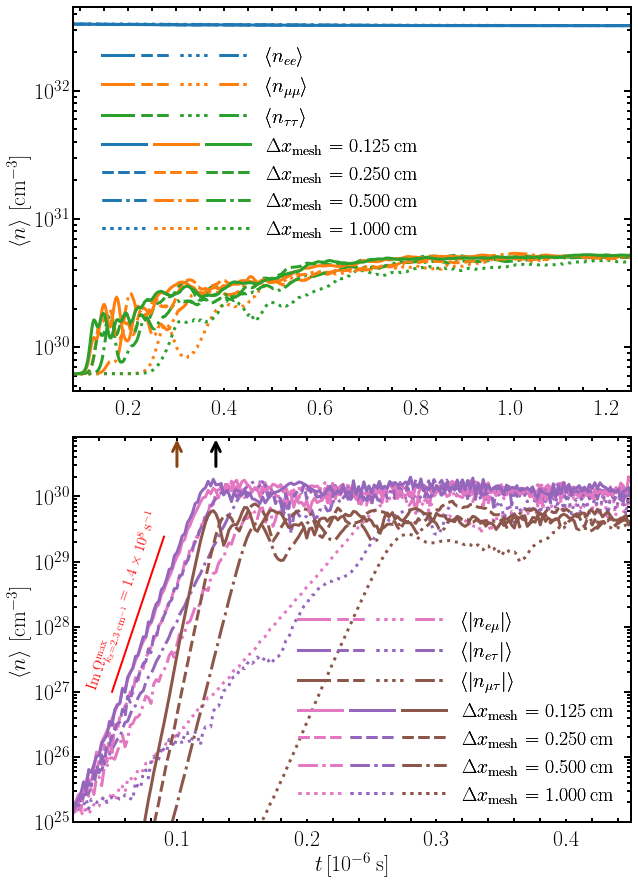

In [9]:
fig, axs = plt.subplots(
    2, 1, figsize=(10, 15),
    sharex=False, sharey=False, gridspec_kw=dict(hspace=0.12, wspace=0.12)
)

ax_1, ax_2 = axs[0], axs[1]

# ax_3.sharex(ax_1)
# ax_4.sharex(ax_2)

# ax_1.tick_params(labelbottom=False)
# ax_2.tick_params(labelbottom=False)

##############################################################################

nor_val_y=1.0
nor_val_x=1.0e-6

ax_1.plot(time_s_48cells/nor_val_x, n_ee_ave_inv_ccm_48cells/nor_val_y, color='C0', linestyle='dotted', linewidth=3, alpha=1.0)
ax_1.plot(time_s_48cells/nor_val_x, n_uu_ave_inv_ccm_48cells/nor_val_y, color='C1', linestyle='dotted', linewidth=3, alpha=1.0)
ax_1.plot(time_s_48cells/nor_val_x, n_tt_ave_inv_ccm_48cells/nor_val_y, color='C2', linestyle='dotted', linewidth=3, alpha=1.0)

ax_1.plot(time_s_96cells/nor_val_x, n_ee_ave_inv_ccm_96cells/nor_val_y, color='C0', linestyle='dashdot', linewidth=3, alpha=1.0)
ax_1.plot(time_s_96cells/nor_val_x, n_uu_ave_inv_ccm_96cells/nor_val_y, color='C1', linestyle='dashdot', linewidth=3, alpha=1.0)
ax_1.plot(time_s_96cells/nor_val_x, n_tt_ave_inv_ccm_96cells/nor_val_y, color='C2', linestyle='dashdot', linewidth=3, alpha=1.0)

ax_1.plot(time_s_192cells/nor_val_x, n_ee_ave_inv_ccm_192cells/nor_val_y, color='C0', linestyle='dashed', linewidth=3, alpha=1.0)
ax_1.plot(time_s_192cells/nor_val_x, n_uu_ave_inv_ccm_192cells/nor_val_y, color='C1', linestyle='dashed', linewidth=3, alpha=1.0)
ax_1.plot(time_s_192cells/nor_val_x, n_tt_ave_inv_ccm_192cells/nor_val_y, color='C2', linestyle='dashed', linewidth=3, alpha=1.0)

ax_1.plot(time_s_384cells/nor_val_x, n_ee_ave_inv_ccm_384cells/nor_val_y, color='C0', linestyle='solid', linewidth=3, alpha=1.0)
ax_1.plot(time_s_384cells/nor_val_x, n_uu_ave_inv_ccm_384cells/nor_val_y, color='C1', linestyle='solid', linewidth=3, alpha=1.0)
ax_1.plot(time_s_384cells/nor_val_x, n_tt_ave_inv_ccm_384cells/nor_val_y, color='C2', linestyle='solid', linewidth=3, alpha=1.0)

ax_1.set_ylabel(r'$ \left< n \right> \, [\mathrm{cm}^{-3}]$',fontsize=22)

handles_1_1 = [
    (
        Line2D([], [], color='C0', linestyle='solid', lw=3, alpha=1.0),
        Line2D([], [], color='C0', linestyle='dashed', lw=3, alpha=1.0),
        Line2D([], [], color='C0', linestyle='dotted', lw=3, alpha=1.0),
        Line2D([], [], color='C0', linestyle='dashdot', lw=3, alpha=1.0),
    ),
    (
        Line2D([], [], color='C1', linestyle='solid', lw=3, alpha=1.0),
        Line2D([], [], color='C1', linestyle='dashed', lw=3, alpha=1.0),
        Line2D([], [], color='C1', linestyle='dotted', lw=3, alpha=1.0),
        Line2D([], [], color='C1', linestyle='dashdot', lw=3, alpha=1.0),
    ),
    (
        Line2D([], [], color='C2', linestyle='solid', lw=3, alpha=1.0),
        Line2D([], [], color='C2', linestyle='dashed', lw=3, alpha=1.0),
        Line2D([], [], color='C2', linestyle='dotted', lw=3, alpha=1.0),
        Line2D([], [], color='C2', linestyle='dashdot', lw=3, alpha=1.0),
    ),
    (
        Line2D([], [], color='C0', linestyle='solid', lw=3, alpha=1.0),
        Line2D([], [], color='C1', linestyle='solid', lw=3, alpha=1.0),
        Line2D([], [], color='C2', linestyle='solid', lw=3, alpha=1.0),
    ),
    (
        Line2D([], [], color='C0', linestyle='dashed', lw=3, alpha=1.0),
        Line2D([], [], color='C1', linestyle='dashed', lw=3, alpha=1.0),
        Line2D([], [], color='C2', linestyle='dashed', lw=3, alpha=1.0),
    ),
    (
        Line2D([], [], color='C0', linestyle='dashdot', lw=3, alpha=1.0),
        Line2D([], [], color='C1', linestyle='dashdot', lw=3, alpha=1.0),
        Line2D([], [], color='C2', linestyle='dashdot', lw=3, alpha=1.0),
    ),
    (
        Line2D([], [], color='C0', linestyle='dotted', lw=3, alpha=1.0),
        Line2D([], [], color='C1', linestyle='dotted', lw=3, alpha=1.0),
        Line2D([], [], color='C2', linestyle='dotted', lw=3, alpha=1.0),
    ),
]
labels_1_1  = [
    r'$\left< n_{ee}        \right>$',
    r'$\left< n_{\mu\mu}    \right>$',
    r'$\left< n_{\tau\tau}  \right>$',
    r'$\Delta x_\mathrm{mesh}=0.125\,\mathrm{cm}$',
    r'$\Delta x_\mathrm{mesh}=0.250\,\mathrm{cm}$',
    r'$\Delta x_\mathrm{mesh}=0.500\,\mathrm{cm}$',
    r'$\Delta x_\mathrm{mesh}=1.000\,\mathrm{cm}$',
]
# first legend: injection lines only –- make them long
leg_1_1 = ax_1.legend(
    handles_1_1, labels_1_1,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    handlelength=7.4,        # ← long lines here
    ncol=1, fontsize=20, framealpha=0.0,
    loc='lower right',        # base location
    bbox_to_anchor=(0.65, 0.35)
)

ax_1.add_artist(leg_1_1)        # keep it when we add the second legend
pf.apply_custom_settings(ax_1, leg_1_1, log_scale_y=True)
ax_1.set_xlim(0.085, 1.25)
# ax_1.grid(True, which='both', linestyle=':', linewidth=1, alpha=0.8)

##############################################################################

nor_val_y=1.0
nor_val_x=1.0e-6

ax_2.plot(time_s_48cells/nor_val_x, n_eu_ave_inv_ccm_48cells/nor_val_y, color='C6', linestyle='dotted', linewidth=3, alpha=1.0)
ax_2.plot(time_s_48cells/nor_val_x, n_et_ave_inv_ccm_48cells/nor_val_y, color='C4', linestyle='dotted', linewidth=3, alpha=1.0)
ax_2.plot(time_s_48cells/nor_val_x, n_ut_ave_inv_ccm_48cells/nor_val_y, color='C5', linestyle='dotted', linewidth=3, alpha=1.0)
    
ax_2.plot(time_s_96cells/nor_val_x, n_eu_ave_inv_ccm_96cells/nor_val_y, color='C6', linestyle='dashdot', linewidth=3, alpha=1.0)
ax_2.plot(time_s_96cells/nor_val_x, n_et_ave_inv_ccm_96cells/nor_val_y, color='C4', linestyle='dashdot', linewidth=3, alpha=1.0)
ax_2.plot(time_s_96cells/nor_val_x, n_ut_ave_inv_ccm_96cells/nor_val_y, color='C5', linestyle='dashdot', linewidth=3, alpha=1.0)


ax_2.plot(time_s_192cells/nor_val_x, n_eu_ave_inv_ccm_192cells/nor_val_y, color='C6', linestyle='dashed', linewidth=3, alpha=1.0, label=r'$n_{e\mu}$')
ax_2.plot(time_s_192cells/nor_val_x, n_et_ave_inv_ccm_192cells/nor_val_y, color='C4', linestyle='dashed', linewidth=3, alpha=1.0, label=r'$n_{e\tau}$')
ax_2.plot(time_s_192cells/nor_val_x, n_ut_ave_inv_ccm_192cells/nor_val_y, color='C5', linestyle='dashed', linewidth=3, alpha=1.0, label=r'$n_{\mu\tau}$')

ax_2.plot(time_s_384cells/nor_val_x, n_eu_ave_inv_ccm_384cells/nor_val_y, color='C6', linestyle='solid', linewidth=3, alpha=1.0)
ax_2.plot(time_s_384cells/nor_val_x, n_et_ave_inv_ccm_384cells/nor_val_y, color='C4', linestyle='solid', linewidth=3, alpha=1.0)
ax_2.plot(time_s_384cells/nor_val_x, n_ut_ave_inv_ccm_384cells/nor_val_y, color='C5', linestyle='solid', linewidth=3, alpha=1.0)

ax_2.set_ylabel(r'$\left< n \right> \, [\mathrm{cm}^{-3}]$', fontsize=22)

#####################################
# Plotting most unstable mode
Omega_inv_s = 137139943.8184736 # in 1/s
k_x_inv_cm = 2.29 # in 1/cm

A = 1e27 / np.exp(Omega_inv_s * 0.05e-6)
time_LSA = np.linspace(0.05, 0.09, 20)*1e-6  # in s
print("time_LSA =", time_LSA)
y = A * np.exp(Omega_inv_s * time_LSA)
print("y =", y)
print("A =", A)
ax_2.plot(time_LSA/1e-6, y/nor_val_y, color='red', linestyle='solid', linewidth=2.0, alpha=1.0)
fig.text(
    0.14, 0.33,
    r'$\mathrm{Im} \, \Omega^{\mathrm{max}}_{k_x=2.3\,\mathrm{cm}^{-1}} = 1.4\times 10^{8} \,\mathrm{s}^{-1}$',
    va='center', color='red', rotation=71, fontsize=15
)

#####################################


handles_2_1 = [
    (
        Line2D([], [], color='C6', linestyle='solid', lw=3, alpha=1.0),
        Line2D([], [], color='C6', linestyle='dashed', lw=3, alpha=1.0),
        Line2D([], [], color='C6', linestyle='dotted', lw=3, alpha=1.0),
        Line2D([], [], color='C6', linestyle='dashdot', lw=3, alpha=1.0),
    ),
    (
        Line2D([], [], color='C4', linestyle='solid', lw=3, alpha=1.0),
        Line2D([], [], color='C4', linestyle='dashed', lw=3, alpha=1.0),
        Line2D([], [], color='C4', linestyle='dotted', lw=3, alpha=1.0),
        Line2D([], [], color='C4', linestyle='dashdot', lw=3, alpha=1.0),
    ),
    (
        Line2D([], [], color='C5', linestyle='solid', lw=3, alpha=1.0),
        Line2D([], [], color='C5', linestyle='dashed', lw=3, alpha=1.0),
        Line2D([], [], color='C5', linestyle='dotted', lw=3, alpha=1.0),
        Line2D([], [], color='C5', linestyle='dashdot', lw=3, alpha=1.0),
    ),
    (
        Line2D([], [], color='C6', linestyle='solid', lw=3, alpha=1.0),
        Line2D([], [], color='C4', linestyle='solid', lw=3, alpha=1.0),
        Line2D([], [], color='C5', linestyle='solid', lw=3, alpha=1.0),
    ),
    (
        Line2D([], [], color='C6', linestyle='dashed', lw=3, alpha=1.0),
        Line2D([], [], color='C4', linestyle='dashed', lw=3, alpha=1.0),
        Line2D([], [], color='C5', linestyle='dashed', lw=3, alpha=1.0),
    ),
    (
        Line2D([], [], color='C6', linestyle='dashdot', lw=3, alpha=1.0),
        Line2D([], [], color='C4', linestyle='dashdot', lw=3, alpha=1.0),
        Line2D([], [], color='C5', linestyle='dashdot', lw=3, alpha=1.0),
    ),
    (
        Line2D([], [], color='C6', linestyle='dotted', lw=3, alpha=1.0),
        Line2D([], [], color='C4', linestyle='dotted', lw=3, alpha=1.0),
        Line2D([], [], color='C5', linestyle='dotted', lw=3, alpha=1.0),
    ),
]
labels_2_1  = [
    r'$\left< \left|n_{e\mu}\right   | \right>$',
    r'$\left< \left|n_{e\tau}\right  | \right>$',
    r'$\left< \left|n_{\mu\tau}\right| \right>$',
    r'$\Delta x_\mathrm{mesh}=0.125\,\mathrm{cm}$',
    r'$\Delta x_\mathrm{mesh}=0.250\,\mathrm{cm}$',
    r'$\Delta x_\mathrm{mesh}=0.500\,\mathrm{cm}$',
    r'$\Delta x_\mathrm{mesh}=1.000\,\mathrm{cm}$',
]
# first legend: injection lines only –- make them long
leg_2_1 = ax_2.legend(
    handles_2_1, labels_2_1,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    handlelength=7.4,        # ← long lines here
    ncol=1, fontsize=20, framealpha=0.0,
    loc='lower right',        # base location
    # bbox_to_anchor=(0.10, 0.80)
)

ax_2.add_artist(leg_2_1)        # keep it when we add the second legend
pf.apply_custom_settings(ax_2, leg_2_1, log_scale_y=True)
ax_2.set_ylim(1e25, None)
ax_2.set_xlim(0.02, 0.45)
ax_2.set_xlabel(r'$t \, [10^{-6}\,\mathrm{s}]$', style="italic", fontsize=22)
# ax_2.grid(True, which='both', linestyle=':', linewidth=1, alpha=0.8)

# fig.text(0.034, 0.5, r'$n \, [\mathrm{cm}^{-3}]$', va='center', rotation='vertical', fontsize=22)

ylow, yhigh = ax_2.get_ylim()
ax_2.annotate('', xy=(0.13, yhigh), xytext=(0.13, yhigh/3), arrowprops=dict(arrowstyle='->', color='black', lw=3, alpha=1.0))
ax_2.annotate('', xy=(0.10, yhigh), xytext=(0.10, yhigh/3), arrowprops=dict(arrowstyle='->', color='saddlebrown', lw=3, alpha=1.0))

##############################################################################

plt.savefig('plots/n_average_FFI.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)